In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### What is a Neural Network?

A **neural network** is a series of interconnected **"neurons"** that process information, inspired by the human brain.

#### How It Works

| Layer | What it does |
|-------|--------------|
| **Input Layer** | Receives raw data (features) |
| **Hidden Layer(s)** | Learns patterns and transformations |
| **Output Layer** | Produces final prediction |

```mermaid
graph LR
    subgraph Input["Input Layer"]
        I1[x1]
        I2[x2]
        I3[x3]
    end
    
    subgraph Hidden["Hidden Layer(s)"]
        H1[●]
        H2[●]
        H3[●]
    end
    
    subgraph Output["Output Layer"]
        O1[●]
        O2[●]
    end
    
    I1 --> H1
    I1 --> H2
    I1 --> H3
    I2 --> H1
    I2 --> H2
    I2 --> H3
    I3 --> H1
    I3 --> H2
    I3 --> H3
    
    H1 --> O1
    H2 --> O1
    H3 --> O1
    H1 --> O2
    H2 --> O2
    H3 --> O2
```

#### The Perceptron

A **perceptron** is the building block of neural networks:

$$
z = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

$$
y = \text{activation\_function}(z)
$$

#### Perceptron: Step-by-Step Process

| Step | Action | Formula |
|------|--------|---------|
| 1 | Inputs enter the neuron | $x_1, x_2, x_3$ |
| 2 | Multiply by weights | $x_1 \cdot w_1, \; x_2 \cdot w_2, \; x_3 \cdot w_3$ |
| 3 | Sum everything + bias | $z = \sum (x_i \cdot w_i) + b$ |
| 4 | Pass through activation | $y = f(z)$ |
| 5 | Output passes to next layer | $y$ |

```mermaid
graph LR
    A["Step 1: Inputs<br>x₁, x₂, x₃"] --> B["Step 2: Multiply by Weights<br>x₁·w₁, x₂·w₂, x₃·w₃"]
    B --> C["Step 3: Sum + Bias<br>z = Σ(xᵢ·wᵢ) + b"]
    C --> D["Step 4: Activation<br>y = f(z)"]
    D --> E["Step 5: Output<br>y"]
```

#### Common Activation Functions

| Function | Formula | Range | Use Case |
|----------|---------|-------|----------|
| **Sigmoid** | $\frac{1}{1 + e^{-z}}$ | (0, 1) | Binary classification |
| **Tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | (-1, 1) | Hidden layers |
| **ReLU** | $\max(0, z)$ | [0, ∞) | Hidden layers (default) |
| **Linear** | $z$ | (-∞, ∞) | Regression |

#### Binary Cross-Entropy Loss Formula

$$
\text{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]
$$

| Term | Description |
|------|-------------|
| $N$ | Number of samples |
| $y_i$ | True label (0 or 1) |
| $\hat{y}_i$ | Predicted probability (between 0 and 1) |

In [5]:
############

#### Example:

| Part | Code | Role |
|------|------|------|
| **Input** | `[1, 0, 1]` | The actual input vector ($x_1, x_2, x_3$) |
| **Weights** | `[0.5, -0.3, 0.8]` | Multipliers for each input |
| **Bias** | `0.1` | Shift added to the sum |

$$
z = w_1 x_1 + w_2 x_2 + w_3 x_3 + b
$$

$$
z = (0.5)(1) + (-0.3)(0) + (0.8)(1) + 0.1
$$

$$
z = 0.5 + 0 + 0.8 + 0.1 = 1.4
$$

$$
y = \text{sigmoid}(1.4) = \frac{1}{1 + e^{-1.4}} \approx 0.802
$$


In [4]:
# simple example
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

weights=[0.5, -0.3, 0.8]
bias=0.1
inputs=[1, 0, 1]

p = Perceptron(weights=weights, bias=bias)
output = p.predict(X=inputs)
print(f"Output: {output:.4f}")

Output: 0.8022


#### Simple classificatio example:

In [37]:
class Perceptron:
    """A simple perceptron implementation from scratch."""
    def __init__(self, n_features, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        
        self.weights = np.random.randn(n_features) * 0.01 # normal random weights
        self.bias = 0

        # for visulaization
        self.loss_history = []
        self.accuracy_history = []
    
    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # clip to avoid overflow
    
    def forward(self, X):
        """Forward pass: compute predictions"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        eps = 1e-15 # small epsilon to avoid log(0)
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def fit(self, X, y):
        """Train the perceptron"""
        for i in range(self.n_iterations):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Compute gradient (derivative of loss w.r.t weights)
            # For binary cross-entropy with sigmoid:
            # dL/dw = (y_pred - y) * X
            error = y_pred - y
            gradient_weights = np.dot(X.T, error) / len(X)
            gradient_bias = np.mean(error)
            
            # Update weights and bias
            self.weights -= self.learning_rate * gradient_weights
            self.bias -= self.learning_rate * gradient_bias
            
            # Calculate accuracy every 100 iterations
            if i % 100 == 0:
                y_pred_binary = (y_pred > 0.5).astype(int)
                acc = accuracy_score(y, y_pred_binary)
                self.accuracy_history.append(acc)
                if i % 500 == 0:
                    print(f"Iteration {i}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")
    
    def predict(self, X):
        """Predict class labels"""
        y_pred = self.forward(X)
        return (y_pred > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Predict probabilities 
        predict_proba() returns the probability that a point belongs to class 1 (the positive class)."""
        return self.forward(X)

In [49]:
# data
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = Perceptron(
    n_features=X.shape[1],
    learning_rate=0.1,
    n_iterations=2000
)
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Weights: {model.weights}")
print(f"Bias: {model.bias:.4f}")
print("\nHow weights affect prediction:")
print(f"Class 0 prediction: {model.predict_proba(np.array([[0, 0]]))[0]:.4f}")
print(f"Class 1 prediction: {model.predict_proba(np.array([[2, 2]]))[0]:.4f}")

Iteration 0: Loss = 0.6995, Accuracy = 0.0850
Iteration 500: Loss = 0.3248, Accuracy = 0.8725
Iteration 1000: Loss = 0.3234, Accuracy = 0.8725
Iteration 1500: Loss = 0.3233, Accuracy = 0.8750

Test Accuracy: 0.8800
Weights: [0.51847361 2.4230329 ]
Bias: -0.9053

How weights affect prediction:
Class 0 prediction: 0.2880
Class 1 prediction: 0.9932


In [51]:
# For point [0, 0] -> x=0, y=0:
# z = w1*0 + w2*0 + b = -0.9053 
# probability = sigmoid(-0.9053) = 0.29

# For point [2, 2] -> x=2, y=2:
# z = w1*2 + w2*2 + b = 4.9777
# probability = sigmoid(4.9777) = 0.99
 
# Class 0: Inputs like [0, 0] → z < 0 → probability < 0.5
# Class 1: Inputs like [2, 2] → z > 0 → probability > 0.5

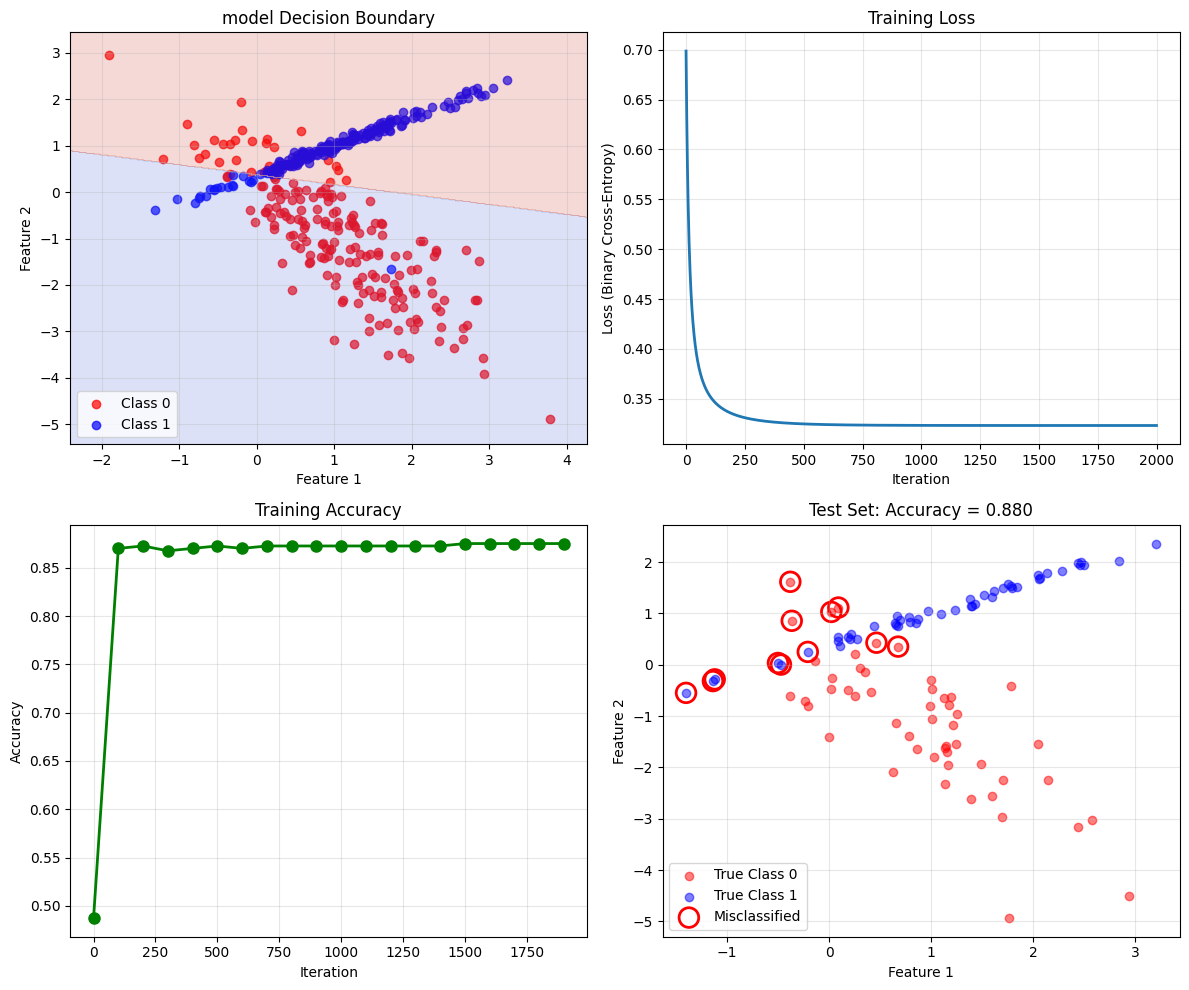

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Data and decision boundary
ax = axes[0, 0]
colors = ['red', 'blue']
for i, label in enumerate([0, 1]):
    mask = y_train == label
    ax.scatter(X_train[mask, 0], X_train[mask, 1], c=colors[i], label=f'Class {label}', alpha=0.7)

# Plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
ax.set_title('model Decision Boundary')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Loss history
ax = axes[0, 1]
ax.plot(model.loss_history, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (Binary Cross-Entropy)')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

# Plot 3: Accuracy over time
ax = axes[1, 0]
iterations = np.arange(0, model.n_iterations, 100)
ax.plot(iterations, model.accuracy_history, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Iteration')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy')
ax.grid(True, alpha=0.3)

# Plot 4: Test predictions
ax = axes[1, 1]
for i, label in enumerate([0, 1]):
    mask = y_test == label
    ax.scatter(X_test[mask, 0], X_test[mask, 1], c=colors[i], marker='o', label=f'True Class {label}', alpha=0.5)

# Highlight misclassifications
y_pred_test = model.predict(X_test)
misclassified = y_pred_test != y_test
ax.scatter(X_test[misclassified, 0], X_test[misclassified, 1], s=200, facecolors='none', edgecolors='red', linewidths=2, label='Misclassified')
ax.set_title(f'Test Set: Accuracy = {accuracy:.3f}')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

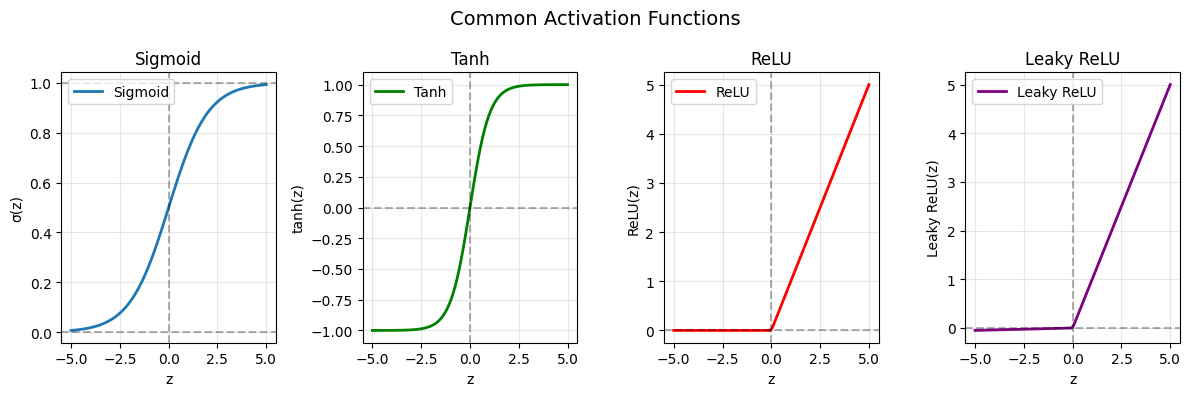

In [50]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

# Generate x values
z = np.linspace(-5, 5, 100)

# Plot activation functions
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.plot(z, sigmoid(z), linewidth=2, label='Sigmoid')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Sigmoid')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(z, tanh(z), linewidth=2, label='Tanh', color='green')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('z')
plt.ylabel('tanh(z)')
plt.title('Tanh')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(z, relu(z), linewidth=2, label='ReLU', color='red')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('z')
plt.ylabel('ReLU(z)')
plt.title('ReLU')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(z, leaky_relu(z), linewidth=2, label='Leaky ReLU', color='purple')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.xlabel('z')
plt.ylabel('Leaky ReLU(z)')
plt.title('Leaky ReLU')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Common Activation Functions', fontsize=14)
plt.tight_layout()
plt.show()

| Activation | Output Range | Best For | Problem |
|------------|--------------|----------|---------|
| **Sigmoid** | 0 to 1 | Binary output | Vanishing gradients |
| **Tanh** | -1 to 1 | Hidden layers | Vanishing gradients |
| **ReLU** | 0 to ∞ | Hidden layers ✅ | Dead neurons |
| **Leaky ReLU** | -∞ to ∞ | Hidden layers | Slightly slower |

### The Perceptron in 3 Steps

| Step | What Happens |
|------|--------------|
| **1. Forward Pass** | Input × Weights + Bias → Activation |
| **2. Compute Loss** | Compare prediction to true label |
| **3. Backward Pass** | Update weights to reduce loss |